### 1 . Importing Modules

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

### Importing DataSet

In [116]:
data = pd.read_csv("retail_demand.csv")

### First Five Rows

In [117]:
data.head()

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
0,1,8222,Chennai,Summer,Heater,1849.0363,2117.0487,12
1,2,8222,Bangalore,Monsoon,Heater,1336.9121,1534.1589,26
2,3,8058,Kolkata,Winter,Heater,2320.4793,2631.3738,220
3,4,8091,Chennai,Winter,Raincoat,173.1042,202.8265,51
4,5,8512,Chennai,Autumn,Umbrella,244.9977,245.6155,77


# Data Preprocessing

## Shape of the Dataset

In [118]:
data.shape

(150150, 8)

## Descriptive statistics of the data-sets

In [119]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ID,150150.0,75075.500000,43344.715797,1.0000,37538.250000,75075.5000,112612.7500,150150.0000
Store ID,150150.0,8295.660346,262.577092,8023.0000,8091.000000,8218.0000,8512.0000,8856.0000
Total Price,150149.0,443.145882,526.002548,34.1819,115.964800,275.1802,500.8901,2989.8010
Base Price,150150.0,479.141370,567.839558,40.0020,125.206225,299.2251,541.5735,2999.9451
Units Sold,150150.0,106.588731,79.647093,9.0000,44.000000,78.0000,151.0000,390.0000


## Correlation between features in a dataset

In [120]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['Season']   = le.fit_transform(data['Season'])
data['Product']  = le.fit_transform(data['Product'])
print(data.head())

   ID  Store ID  Location  Season  Product  Total Price  Base Price  \
0   1      8222         1       2        1    1849.0363   2117.0487   
1   2      8222         0       1        1    1336.9121   1534.1589   
2   3      8058         5       3        1    2320.4793   2631.3738   
3   4      8091         1       3        4     173.1042    202.8265   
4   5      8512         1       0        8     244.9977    245.6155   

   Units Sold  
0          12  
1          26  
2         220  
3          51  
4          77  


In [121]:
data.corr()

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
ID,1.000000,0.002283,0.004907,-0.006164,-0.000551,-0.000603,-0.000531,0.000153
Store ID,0.002283,1.000000,0.000780,-0.000391,0.000554,0.002237,0.002384,0.005913
Location,0.004907,0.000780,1.000000,0.000061,-0.004101,-0.004749,-0.004599,-0.006194
Season,-0.006164,-0.000391,0.000061,1.000000,0.000198,-0.004216,-0.004120,0.046131
Product,-0.000551,0.000554,-0.004101,0.000198,1.000000,-0.300912,-0.301475,0.019428
Total Price,-0.000603,0.002237,-0.004749,-0.004216,-0.300912,1.000000,0.998122,-0.027537
Base Price,-0.000531,0.002384,-0.004599,-0.004120,-0.301475,0.998122,1.000000,-0.027590
Units Sold,0.000153,0.005913,-0.006194,0.046131,0.019428,-0.027537,-0.027590,1.000000


## Data types and more information about the data

In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           150150 non-null  int64  
 1   Store ID     150150 non-null  int64  
 2   Location     150150 non-null  int32  
 3   Season       150150 non-null  int32  
 4   Product      150150 non-null  int32  
 5   Total Price  150149 non-null  float64
 6   Base Price   150150 non-null  float64
 7   Units Sold   150150 non-null  int64  
dtypes: float64(2), int32(3), int64(3)
memory usage: 7.4 MB


## Checking for Missing Values

In [123]:
#The Data Contains Missing values
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    1
Base Price     0
Units Sold     0
dtype: int64

In [124]:
S = pd.isnull(data['Total Price'])
data[S]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold
136949,136950,8121,4,2,1,NaN,1673.2009,20


In [125]:
import sys
!{sys.executable} -m pip install missingno

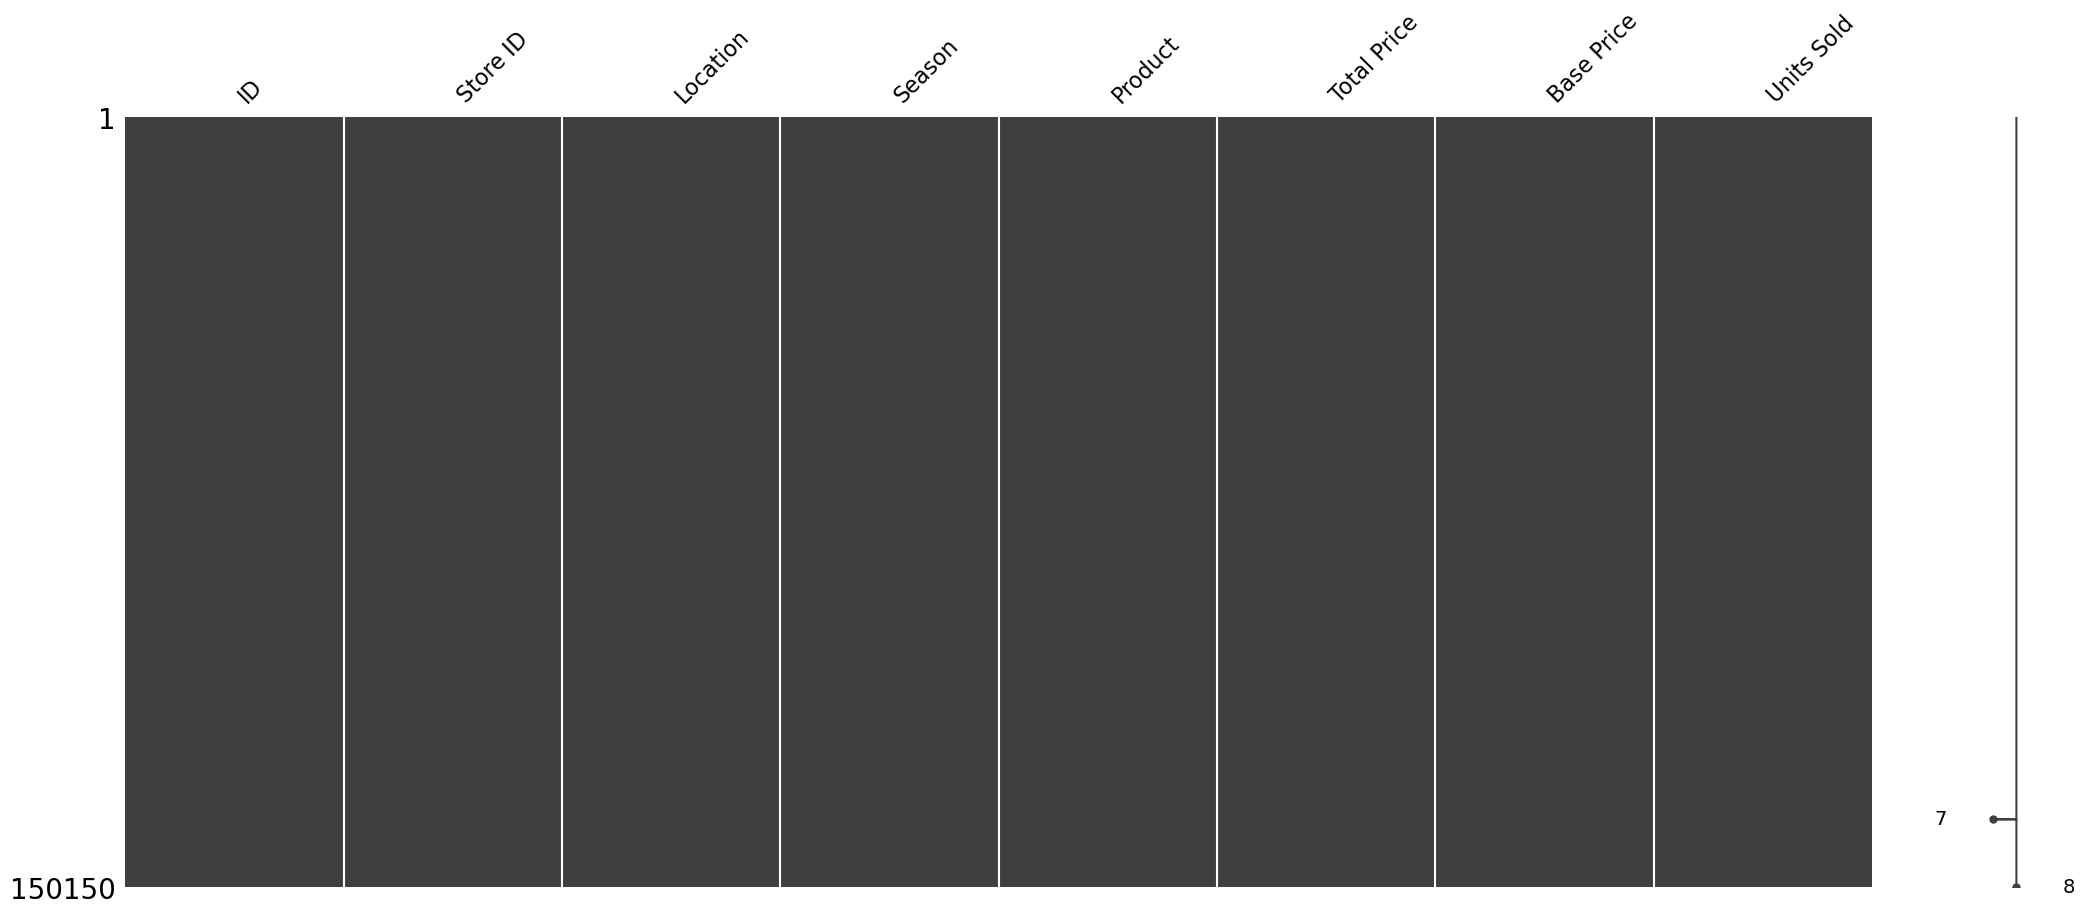

<Figure size 1000x600 with 0 Axes>

In [126]:
import missingno as msno 
msno.matrix(data)
plt.figure(figsize=(10,6))
plt.show()

<Axes: >

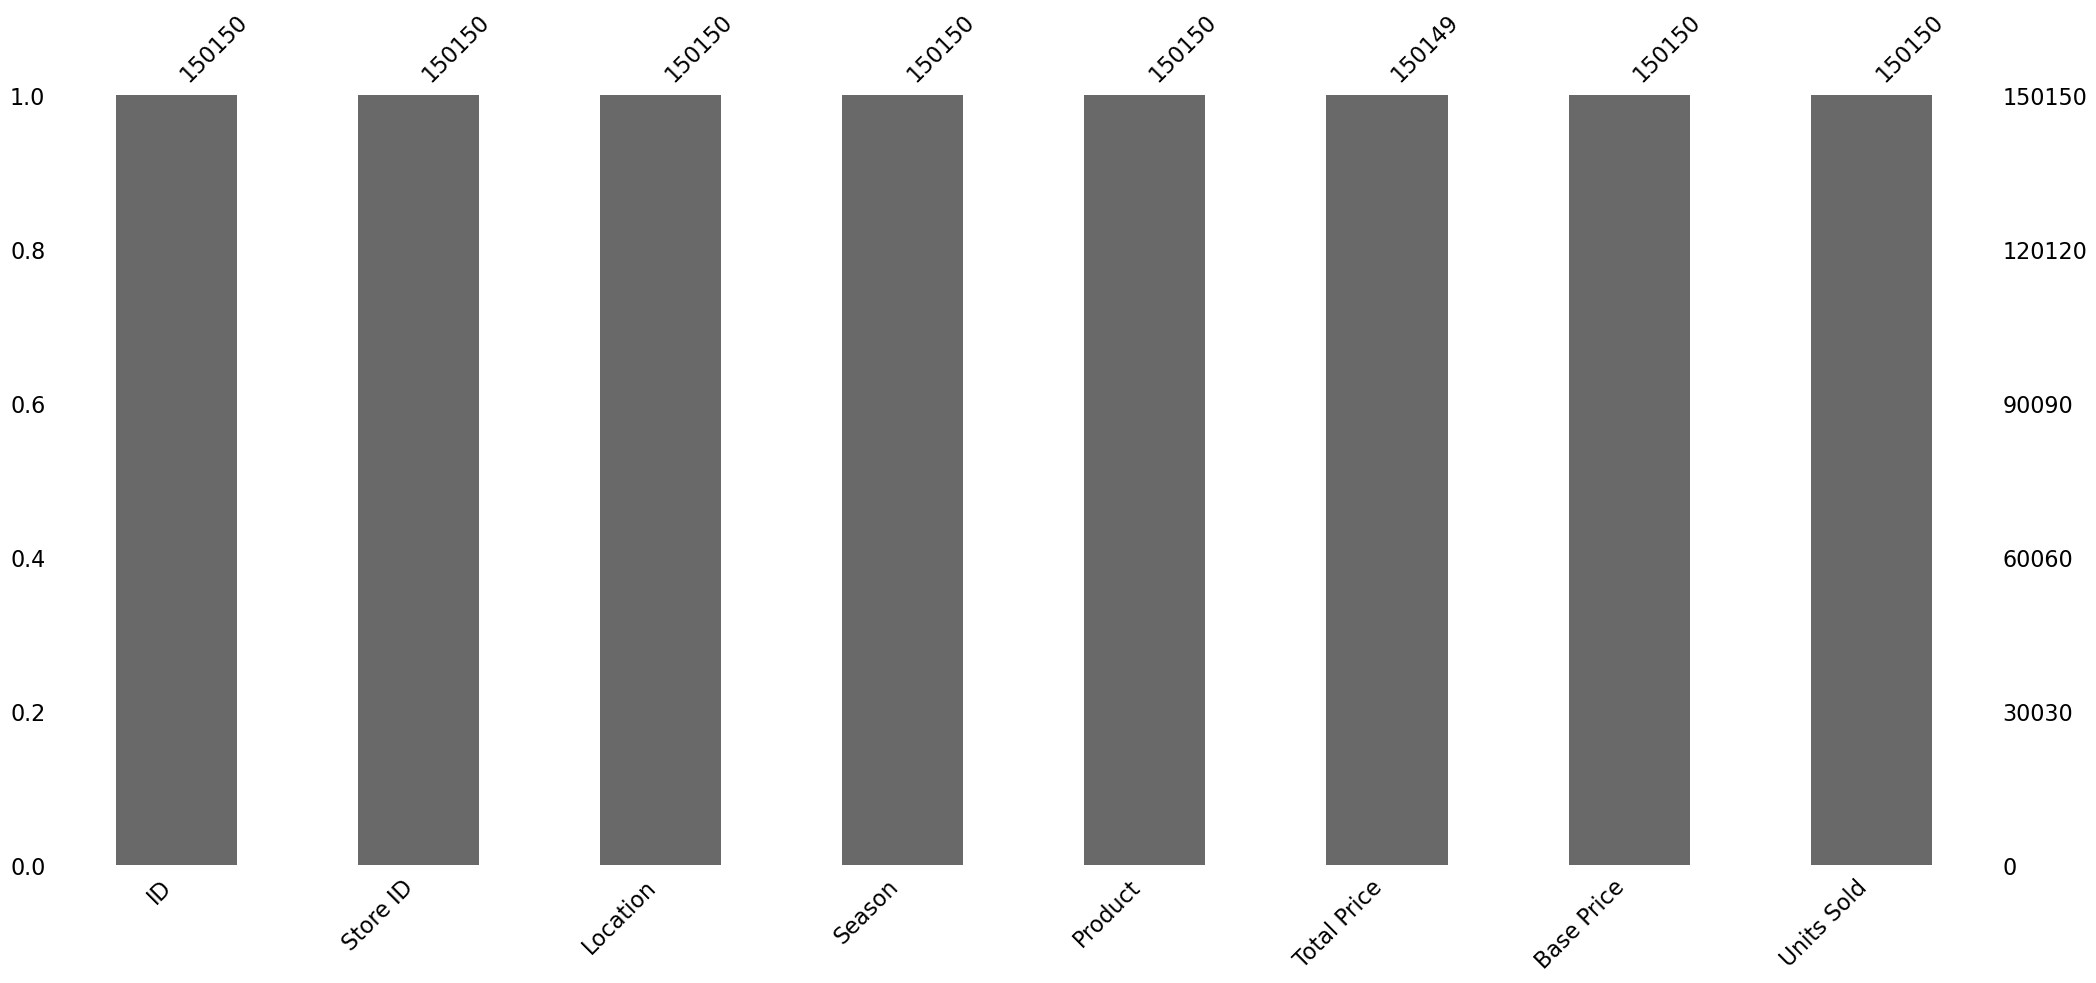

In [127]:
msno.bar(data)

## 1.Delete the missing value

In [128]:
data = data.dropna()

In [129]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Location'] = le.fit_transform(data['Location'])
data['Season']   = le.fit_transform(data['Season'])
data['Product']  = le.fit_transform(data['Product'])

In [130]:
data.shape

(150149, 8)

## 2.Replacing with an arbitrary value

In [131]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [132]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'])

In [133]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [134]:

data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 3.Replacing with the Mean

In [135]:

data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [136]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].mean())

In [137]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [138]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 4.Replacing with the Mode

In [139]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [140]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].mode()[0])

In [141]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [142]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 5.Replacing with the Median

In [143]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [144]:
data['Total Price'] = data['Total Price'].fillna(data['Base Price'].median())

In [145]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [146]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 6.Replacing with the Previous value – forward fill

In [147]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [148]:
data = data.ffill()


In [149]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [150]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 7.Replacing with the Next value – backward fill

In [151]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [152]:
data = data.bfill()

In [153]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [154]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


## 7.Interpolation

In [155]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [156]:
data = data.interpolate()

In [157]:
data.isnull().sum()

ID             0
Store ID       0
Location       0
Season         0
Product        0
Total Price    0
Base Price     0
Units Sold     0
dtype: int64

In [158]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


 ## 8.Multivariate Approach

### 8.1 Iterative Imputer

In [159]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [160]:
X = data[['Total Price','Base Price','Units Sold']]

In [161]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
impute_it = IterativeImputer()
impute_it.fit_transform(X)[136949]

array([417.2535, 429.7936,  42.    ])

### 8.2 KNN Imputer

In [162]:
data[data['Total Price'].isna()]

,ID,Store ID,Location,Season,Product,Total Price,Base Price,Units Sold


In [163]:
X = data[['Total Price','Base Price','Units Sold']]

In [164]:
from sklearn.impute import KNNImputer
impute_knn = KNNImputer(n_neighbors=2)
impute_knn.fit_transform(X)[136949]

array([417.2535, 429.7936,  42.    ])

## Spliting the Data

In [165]:
# Define the features (X) and target variable (y)
X = data[['Store ID', 'Total Price', 'Base Price']]
y = data['Units Sold']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Features Scaling

### 1.Standardization

In [166]:
Std = preprocessing.StandardScaler()
X_train = Std.fit_transform(X_train)
X_test = Std.fit_transform(X_test)
X_train

array([[-2.80777135e-01, -4.96655440e-02, -1.57102137e-03],
       [-2.80777135e-01, -4.77844009e-01, -4.89950969e-01],
       [-2.95995407e-01,  2.54754084e-01,  1.96720425e-01],
       ...,
       [ 8.22547551e-01, -6.69575917e-01, -6.57352348e-01],
       [-6.65038491e-01,  3.60532752e+00,  3.44797956e+00],
       [ 8.06568138e-02, -2.98706749e-01, -2.57883942e-01]])

### 2. Normalization

In [167]:
norm = preprocessing.Normalizer()
X_train=norm.fit_transform(X_train)
X_test=norm.fit_transform(X_test)
X_test

array([[ 0.0931594 , -0.69986041, -0.70817846],
       [-0.60713718, -0.56029723, -0.56342831],
       [-0.96728163, -0.14238148, -0.20998514],
       ...,
       [-0.64318511,  0.58080324,  0.49897946],
       [-0.60211099, -0.56724709, -0.56186573],
       [ 0.29323492,  0.59745412,  0.74636577]])

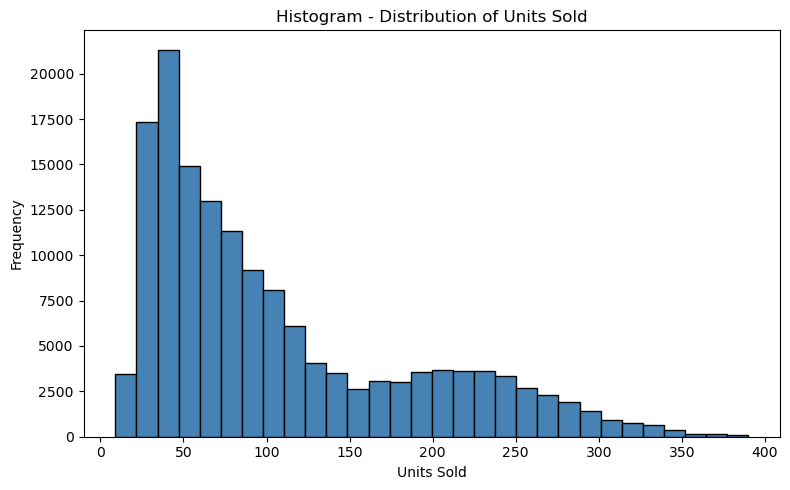

In [168]:
# Histogram - Distribution of Units Sold
plt.figure(figsize=(8, 5))
plt.hist(data['Units Sold'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram - Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\Durgesh\AppData\Local\Temp\ipykernel_30316\3524998491.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(season_data, labels=seasons, patch_artist=True,


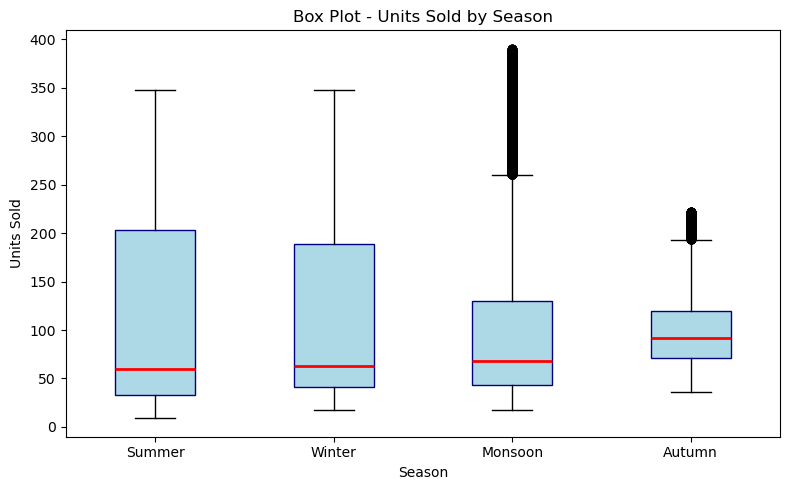

In [169]:
# Box Plot - Units Sold by Season
import pandas as pd
import matplotlib.pyplot as plt

original_data = pd.read_csv("retail_demand.csv").dropna()

plt.figure(figsize=(8, 5))
seasons = ['Summer', 'Winter', 'Monsoon', 'Autumn']
season_data = [original_data[original_data['Season'] == s]['Units Sold'].values for s in seasons]
plt.boxplot(season_data, labels=seasons, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Box Plot - Units Sold by Season')
plt.xlabel('Season')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

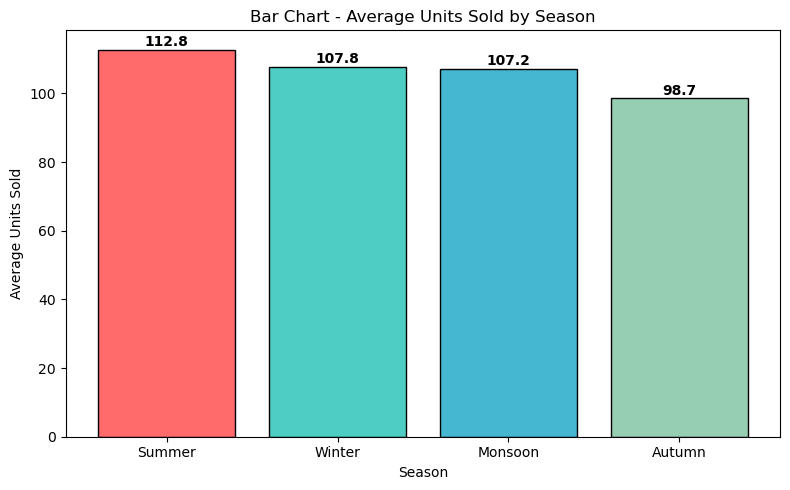

In [170]:
# Bar Chart - Average Units Sold by Season
plt.figure(figsize=(8, 5))
season_avg = original_data.groupby('Season')['Units Sold'].mean().reindex(seasons)
plt.bar(seasons, season_avg.values,
        color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'], edgecolor='black')
plt.title('Bar Chart - Average Units Sold by Season')
plt.xlabel('Season')
plt.ylabel('Average Units Sold')
for i, v in enumerate(season_avg.values):
    plt.text(i, v+1, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

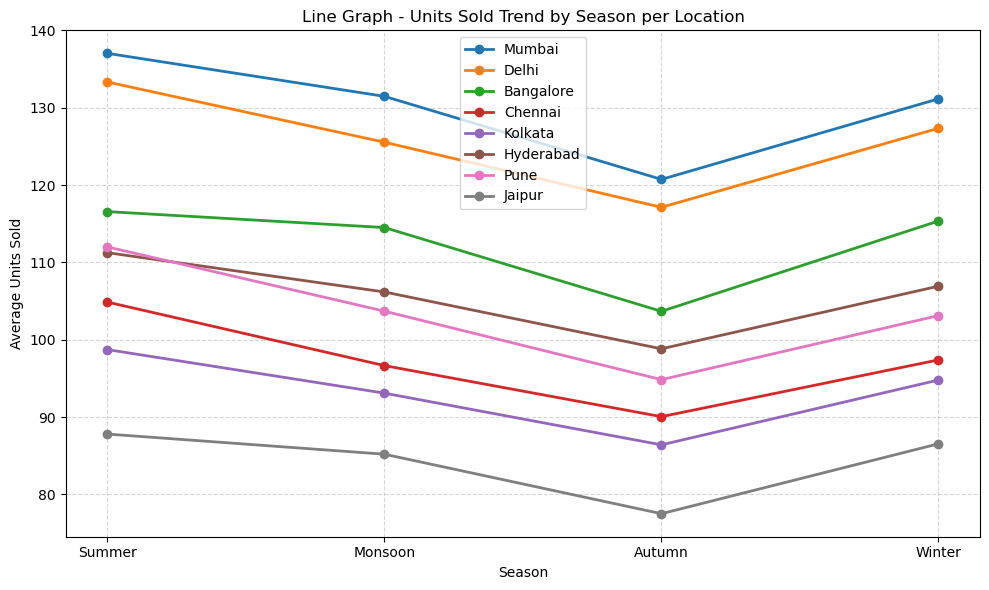

In [171]:
# Line Graph - Units Sold Trend by Season per Location
plt.figure(figsize=(10, 6))
locations = ['Mumbai','Delhi','Bangalore','Chennai','Kolkata','Hyderabad','Pune','Jaipur']
season_order = ['Summer', 'Monsoon', 'Autumn', 'Winter']

for location in locations:
    loc_df = original_data[original_data['Location'] == location]
    avg = loc_df.groupby('Season')['Units Sold'].mean().reindex(season_order)
    plt.plot(season_order, avg.values, marker='o', linewidth=2, label=location)

plt.title('Line Graph - Units Sold Trend by Season per Location')
plt.xlabel('Season')
plt.ylabel('Average Units Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\Durgesh\AppData\Local\Temp\ipykernel_30316\2702270339.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(loc_data, labels=locations, patch_artist=True,


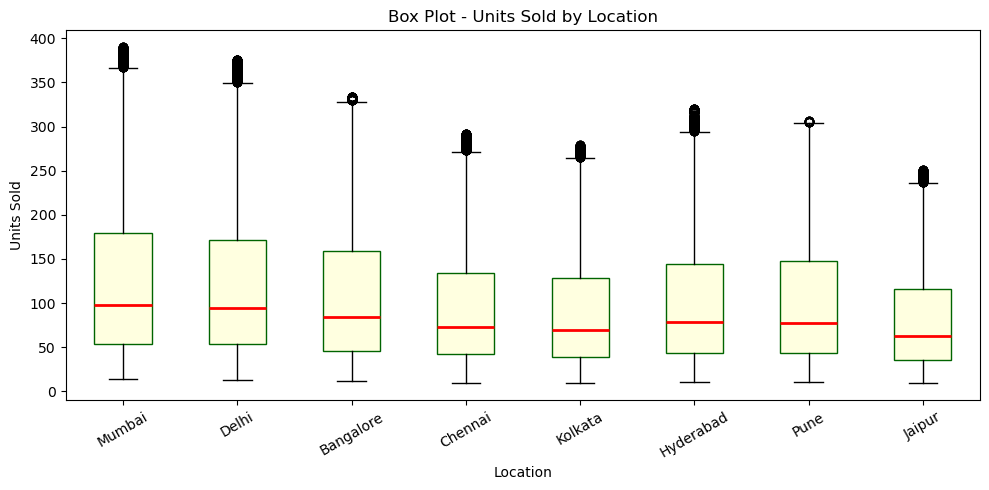

In [172]:
# Box Plot - Units Sold by Location
plt.figure(figsize=(10, 5))
locations = ['Mumbai','Delhi','Bangalore','Chennai','Kolkata','Hyderabad','Pune','Jaipur']
loc_data = [original_data[original_data['Location'] == l]['Units Sold'].values for l in locations]
plt.boxplot(loc_data, labels=locations, patch_artist=True,
            boxprops=dict(facecolor='lightyellow', color='darkgreen'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Box Plot - Units Sold by Location')
plt.xlabel('Location')
plt.ylabel('Units Sold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()